# Proyecto Rappi: análisis de variables relevantes para predecir el tiempo de entrega

Este notebook ayuda a identificar qué columnas aportan valor real para predecir el tiempo de entrega, limpiar variables innecesarias y visualizar las relaciones más importantes antes de entrenar un modelo.

Objetivo principal: estimar el tiempo de entrega en minutos utilizando factores observables antes del envío, sin incluir columnas con fuga de información ni identificadores que solo sirven como claves.

In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [8]:
file_path = 'Food_Delivery_Time_Prediction.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'dharmendrapandit12/food-delivery-time-prediction-dataset',
        file_path,
    )

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.columns = [str(c).strip() for c in df.columns]
display(df.head(5))
display(df.dtypes.to_frame(name='tipo'))

Dimensiones: 50,000 filas x 24 columnas


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.10,3.80,3.80,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.70,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.80,3.60,3.90,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.30,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.80,3.90,4.00,Biryani,1,Low,31,10.15,Long,Moderate,8,28.90,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.70,3.90,4.60,Burger,3,Medium,19,26.33,Long,Low,9,41.40,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.40,4.40,4.00,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.70,Normal,75


,tipo
Order_ID,str
Order_Date,str
Order_Hour,int64
Day_of_Week,str
Is_Weekend,int64
Is_Festival,int64
Weather,str
Pickup_Zone,str
Dropoff_Zone,str
Vehicle_Type,str


## 1. Revisión de columnas relevantes y limpieza inicial

Antes de entrenar cualquier modelo, se deben separar tres tipos de variables:

- Variables objetivo: tiempo de entrega en minutos.
- Variables operativas: distancia, tráfico, clima, zona, condiciones del repartidor, tipo de pedido.
- Variables no útiles o de fuga: IDs, nombres, referencias internas, detalles que no aportan información real para predecir el tiempo a futuro.

La estrategia aquí es detectar columnas por nombre, tipo y relación con la variable objetivo, en lugar de asumir que todas las columnas son útiles.

In [9]:
# --- Helpers de detección ---
def find_column(keywords, default=None):
    if isinstance(keywords, str):
        keywords = [keywords]
    for c in df.columns:
        low = c.lower()
        if all(k.lower() in low for k in keywords):
            return c
    return default

# Objetivo principal: tiempo de entrega
candidate_targets = [
    'time_taken', 'delivery_time', 'delivery_time_min', 'time_taken_min',
    'delivery duration', 'delivery_time_minutes', 'total_time'
]
time_col = None
for key in candidate_targets:
    time_col = find_column(key)
    if time_col is not None:
        break

if time_col is None:
    raise ValueError('No se encontró una columna objetivo de tiempo. Revisa el nombre exacto del CSV.')

df['target_time'] = pd.to_numeric(df[time_col], errors='coerce')
print('Columna objetivo encontrada:', time_col)
print('Resumen objetivo:')
print(df['target_time'].describe())

# Variables operativas relevantes por nombre
traffic_col = find_column(['traffic', 'road_traffic', 'traffic_density'])
weather_col = find_column(['weather', 'climate'])
city_col = find_column(['city'])
festival_col = find_column(['festival'])
vehicle_col = find_column(['vehicle', 'vehicle_condition'])
order_type_col = find_column(['type_of_order', 'order_type'])
restaurant_lat = find_column(['restaurant', 'rest', 'lat'], 'latitude')
restaurant_lon = find_column(['restaurant', 'rest', 'lon'], 'longitude')

# Cálculo de distancia aproximada en km si existen coordenadas
lat_cols = [c for c in df.columns if 'latitude' in c.lower()]
lon_cols = [c for c in df.columns if 'longitude' in c.lower()]

if len(lat_cols) >= 2 and len(lon_cols) >= 2:
    lat1, lat2 = lat_cols[0], lat_cols[1]
    lon1, lon2 = lon_cols[0], lon_cols[1]
    R = 6371.0
    lat1_rad = np.radians(df[lat1].astype(float))
    lat2_rad = np.radians(df[lat2].astype(float))
    dlat = np.radians(df[lat2].astype(float) - df[lat1].astype(float))
    dlon = np.radians(df[lon2].astype(float) - df[lon1].astype(float))
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    df['distance_km'] = 2 * R * np.arcsin(np.sqrt(a))
    print('Se calculó distance_km usando coordenadas del restaurante y destino.')

# Columnas inútiles a filtrar para el modelo
redundant_patterns = [
    'id', 'name', 'address', 'mobile', 'phone', 'email', 'order_id',
    'driver_id', 'restaurant_id', 'delivery_person_id', 'customer_id'
]

columns_to_drop = []
for c in df.columns:
    low = c.lower()
    if c == time_col or c == 'target_time':
        continue
    if any(p in low for p in redundant_patterns):
        columns_to_drop.append(c)

columns_to_drop = list(dict.fromkeys(columns_to_drop))
print('Columnas descartadas por ser identificadores o irrelevantes:', columns_to_drop[:10])

# Variables de interés para el análisis y el modelo
relevant_columns = [
    c for c in df.columns
    if c not in columns_to_drop and c not in [time_col, 'target_time']
]

print('\nVariables potencialmente relevantes:')
for c in relevant_columns[:30]:
    print('-', c)

# Perfil de calidad de columnas
profile = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    '%_faltantes': round(df.isna().mean() * 100, 2),
    'valores_unicos': df.nunique(dropna=True)
}).sort_values(['faltantes', 'valores_unicos'], ascending=[False, True])

display(profile.head(25))

Columna objetivo encontrada: Time_taken_min
Resumen objetivo:
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64
Columnas descartadas por ser identificadores o irrelevantes: ['Order_ID', 'Rider_Experience_Years', 'Rider_Rating']

Variables potencialmente relevantes:
- Order_Date
- Order_Hour
- Day_of_Week
- Is_Weekend
- Is_Festival
- Weather
- Pickup_Zone
- Dropoff_Zone
- Vehicle_Type
- Restaurant_Rating
- Cuisine_Type
- Order_Items
- Restaurant_Load
- Preparation_Time_Min
- Road_Distance_km
- Delivery_Distance_Category
- Traffic_Level
- Number_of_Signals
- Average_Speed_kmph
- Delivery_Priority


,tipo,faltantes,%_faltantes,valores_unicos
Is_Weekend,int64,0,0.00,2
Is_Festival,int64,0,0.00,2
Restaurant_Load,str,0,0.00,3
Delivery_Distance_Category,str,0,0.00,3
Delivery_Priority,str,0,0.00,3
Vehicle_Type,str,0,0.00,4
Traffic_Level,str,0,0.00,4
Weather,str,0,0.00,5
Pickup_Zone,str,0,0.00,5
Dropoff_Zone,str,0,0.00,5


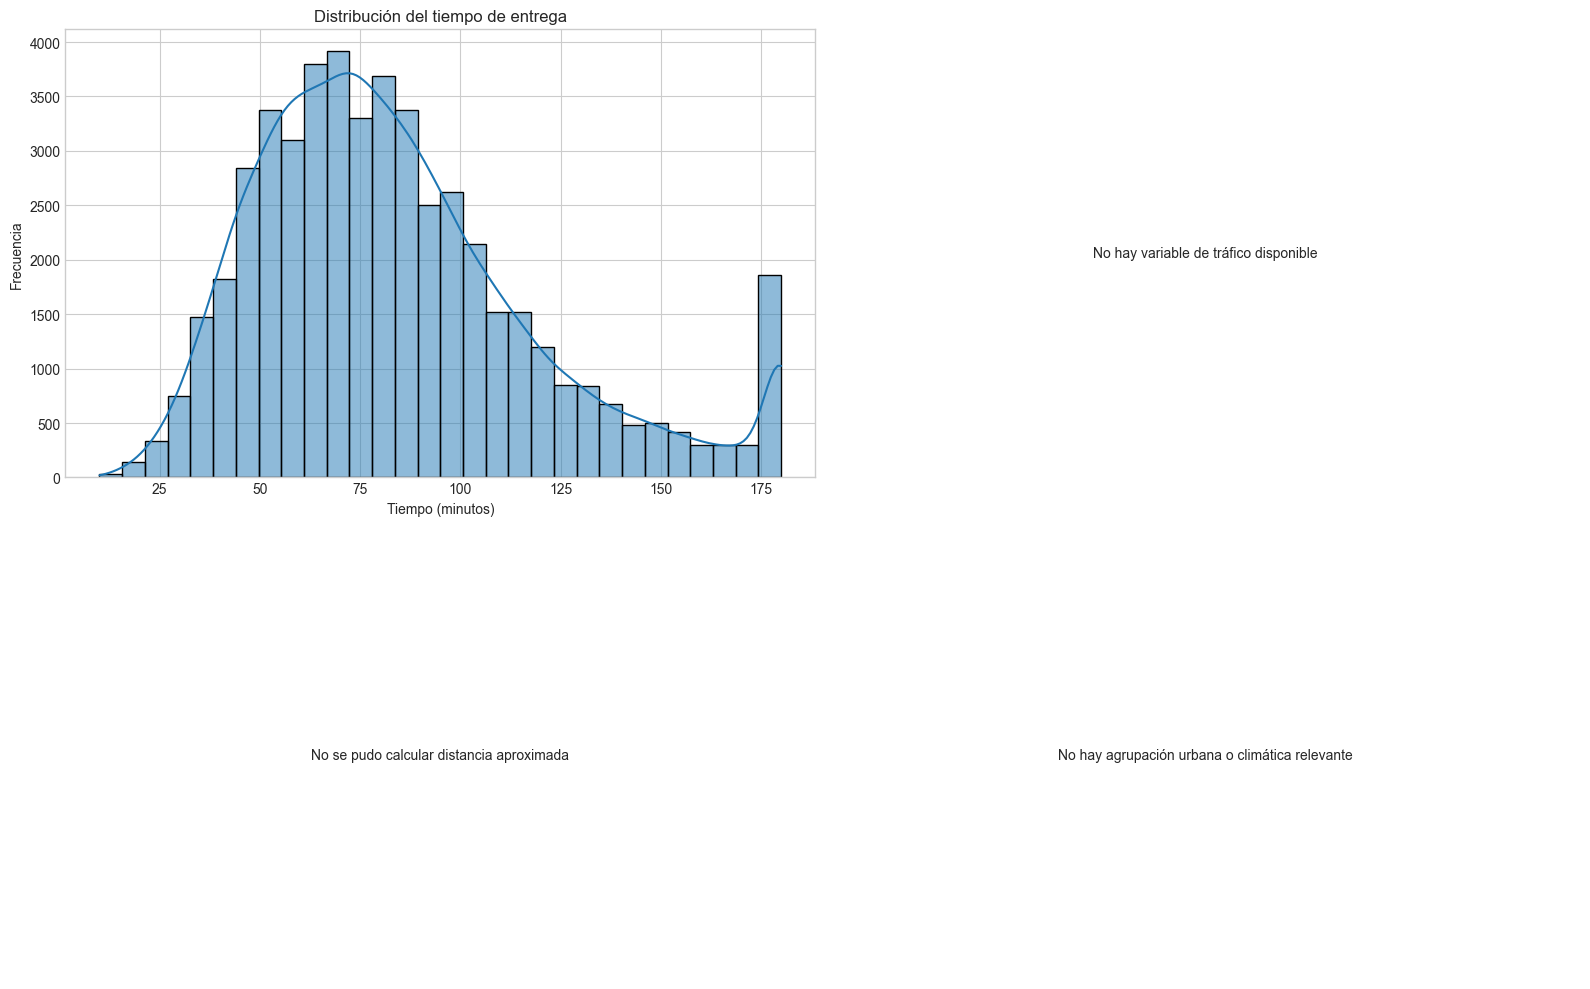

In [10]:
# --- Gráficos 1 a 4: análisis visual de la variable objetivo y relaciones clave ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Histograma del tiempo de entrega
sns.histplot(df['target_time'].dropna(), bins=30, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Distribución del tiempo de entrega')
axes[0, 0].set_xlabel('Tiempo (minutos)')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Boxplot por tráfico si existe
if traffic_col:
    order = ['Low', 'Medium', 'High', 'Very High'] if any(x.lower() in str(df[traffic_col].dropna().unique()).lower() for x in ['low', 'medium', 'high', 'very high']) else None
    sns.boxplot(data=df, x=traffic_col, y='target_time', order=order, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('Tiempo de entrega por nivel de tráfico')
    axes[0, 1].set_xlabel('Tráfico')
    axes[0, 1].set_ylabel('Tiempo (minutos)')
else:
    axes[0, 1].text(0.5, 0.5, 'No hay variable de tráfico disponible', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_axis_off()

# 3. Relación distancia - tiempo si existe
if 'distance_km' in df.columns:
    sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.55, color='#d62728', ax=axes[1, 0])
    axes[1, 0].set_title('Distancia aproximada vs tiempo de entrega')
    axes[1, 0].set_xlabel('Distancia (km)')
    axes[1, 0].set_ylabel('Tiempo (minutos)')
else:
    axes[1, 0].text(0.5, 0.5, 'No se pudo calcular distancia aproximada', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_axis_off()

# 4. Promedio por ciudad o clima si existe
if city_col:
    city_summary = df.groupby(city_col)['target_time'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=city_summary.values, y=city_summary.index, palette='rocket', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por ciudad')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Ciudad')
elif weather_col:
    weather_summary = df.groupby(weather_col)['target_time'].mean().sort_values(ascending=False)
    sns.barplot(x=weather_summary.values, y=weather_summary.index, palette='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por clima')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Clima')
else:
    axes[1, 1].text(0.5, 0.5, 'No hay agrupación urbana o climática relevante', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

# Comentario: si el tráfico o la distancia aumentan, el tiempo normalmente crece de forma clara.
# La relación no es lineal perfecta, pero estos patrones suelen ser los más útiles para explicar y predecir demoras operativas.

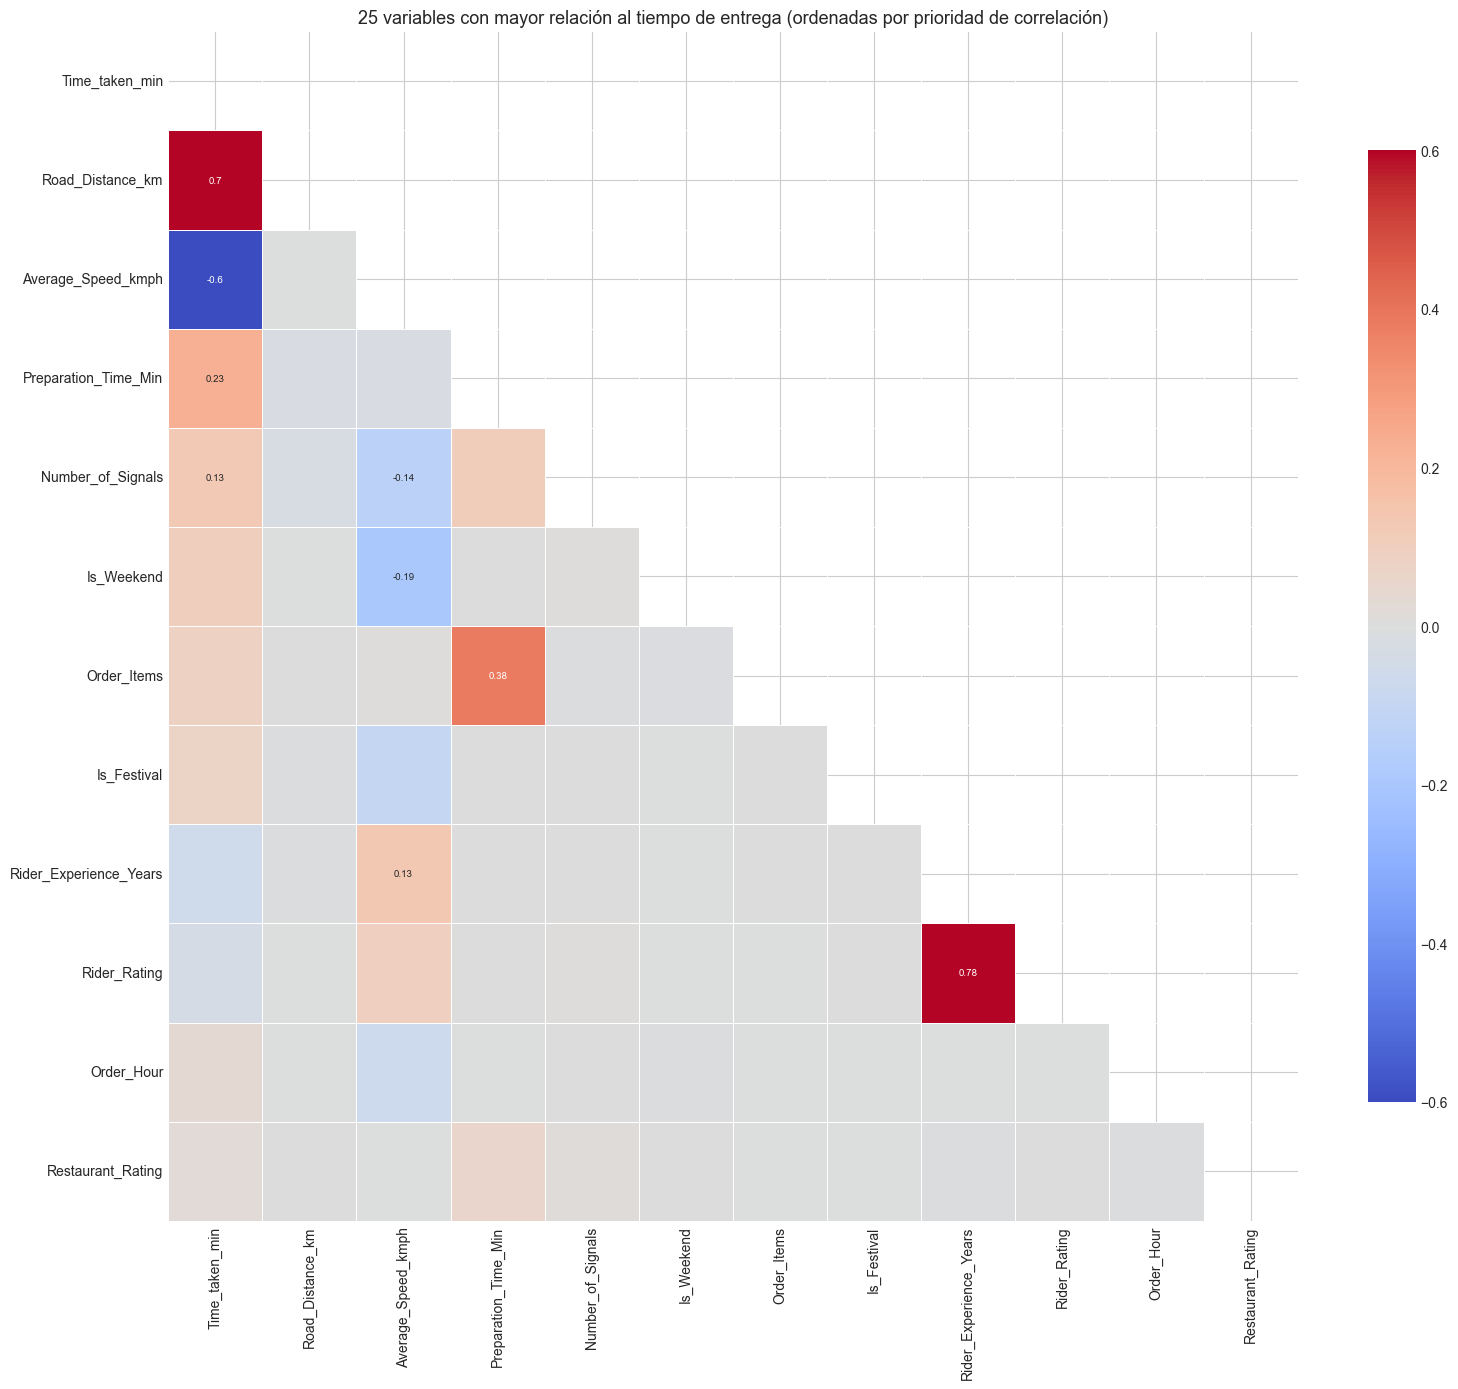

In [11]:
# --- Correlación de las 25 variables más relacionadas con la variable objetivo ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target_time' in num_cols:
    num_cols.remove('target_time')

if len(num_cols) == 0:
    raise ValueError('No hay columnas numéricas para la correlación. Revisa el tipo de datos.')

corr_with_target = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].drop('target_time').abs().sort_values(ascending=False)
ordered_cols = corr_with_target.head(25).index.tolist()

if len(ordered_cols) == 0:
    raise ValueError('No se encontraron variables numéricas relacionadas con el objetivo.')

corr_matrix = df[ordered_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-0.6,
    vmax=0.6,
    center=0,
    annot=np.where(np.abs(corr_matrix) >= 0.12, corr_matrix.round(2).astype(str), ''),
    fmt='',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 7}
)
plt.title('25 variables con mayor relación al tiempo de entrega (ordenadas por prioridad de correlación)', fontsize=13)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Comentario: esta matriz se ordena por fuerza de relación con la variable objetivo.
# En modelos de regresión, los valores más altos en valor absoluto son los candidatos más importantes para analizar primero.
# Los números aparecen solo cuando la correlación es suficientemente relevante para justificar atención.

## 2. Qué variables son más relevantes para este objetivo

Las columnas que más suelen aportar valor para predecir el tiempo de entrega son:

- Distancia estimada entre restaurante y destino.
- Nivel de tráfico o densidad vial.
- Condiciones del clima.
- Ciudad, barrio o zona de entrega.
- Tipo de pedido o modalidad de operación.
- Condiciones del vehículo o del repartidor.
- Tiempo de preparación, recogida y horario del pedido.

Lo más importante es filtrar variables de identidad o ruido:

- IDs y nombres del pedido/repartidor/restaurante.
- Datos no disponibles antes de la entrega.
- Columnas con alta cardinalidad que no tienen sentido como predictores si no se transforman bien.

## 3. Sesgo y desbalance del dataset respecto al objetivo

Para un problema de regresión, el concepto de desbalance no es exactamente el mismo que en clasificación. Aquí la clave es revisar la distribución del tiempo de entrega:

- Si la mayoría de los pedidos se concentran en un rango corto, el modelo puede aprender muy bien ese tramo y fallar en entregas atípicas.
- El sesgo puede aparecer por ciudad, tráfico, clima, tipo de pedido o condiciones del repartidor.
- Si una ciudad o un tipo de tráfico tiene pocas observaciones, el modelo puede generalizar mal para ese segmento.

Si se convierte el problema en clasificación, por ejemplo, entregas rápidas/medias/lentas, sí puede existir desbalance entre clases. En ese caso debe revisarse:

- proporción por clase,
- clase minoritaria,
- métricas por clase y no solo accuracy.

En términos prácticos, el riesgo real no es solo el desbalance, sino que el conjunto de datos tienda a reflejar ventanas operativas muy repetitivas y no represente bien los casos de alta demora. Por eso conviene revisar la distribución por tráfico, ciudad y condiciones climáticas antes de entrenar.

## 4. Recomendación final

La mejor primera estrategia es entrenar una regresión para predecir `Time_taken(min)`, porque conserva la información real del tiempo y permite usar métricas como MAE, RMSE y R².

Luego, si se quiere una versión más operativa, se puede convertir a clasificación de entregas rápidas/medias/lentas o a alerta de entrega tardía, siempre validando el balance por clase y evitando variables que solo se conocen después de la entrega.

Estadísticas de target_time:
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64

Percentiles relevantes:
0.01    26.00
0.05    38.00
0.10    44.00
0.25    58.00
0.50    78.00
0.75   102.00
0.90   133.00
0.95   162.00
0.99   180.00
Name: target_time, dtype: float64

Número total de observaciones: 50,000
Rango intercuartil (IQR): 44.00 min
Coeficiente de variación: 0.422


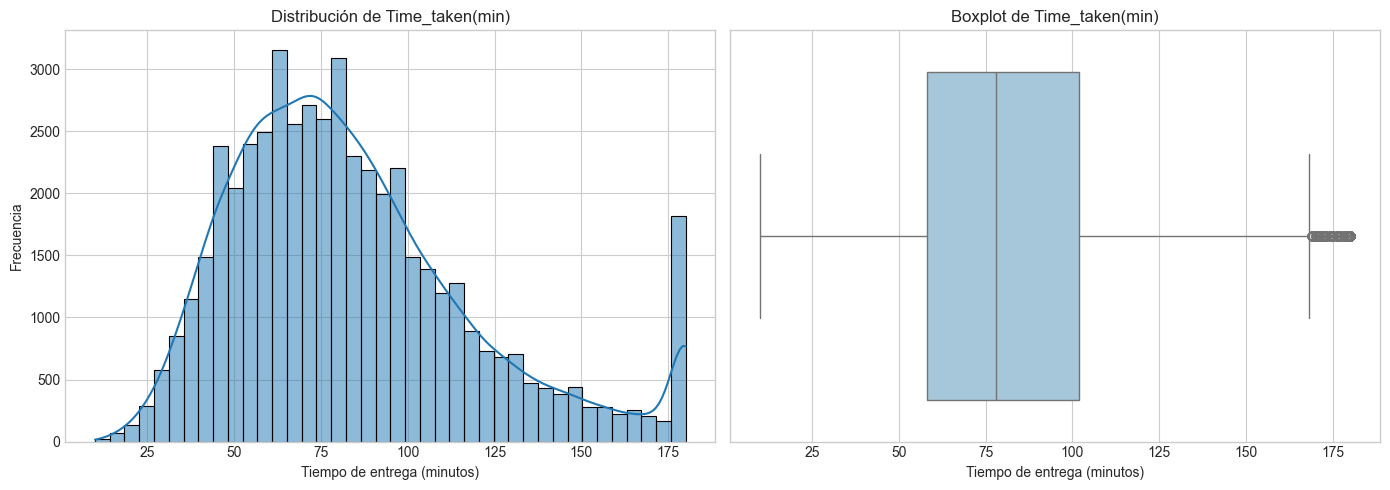

Outliers por IQR: 2,153 observaciones
Rango IQR: [-8.00, 168.00]
count   2153.00
mean     178.53
std        3.09
min      169.00
25%      180.00
50%      180.00
75%      180.00
max      180.00
Name: target_time, dtype: float64

Outliers por z-score > 3: 0 observaciones
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: target_time, dtype: float64
No existe la columna distance_km; la distancia no se calculó en este dataframe.


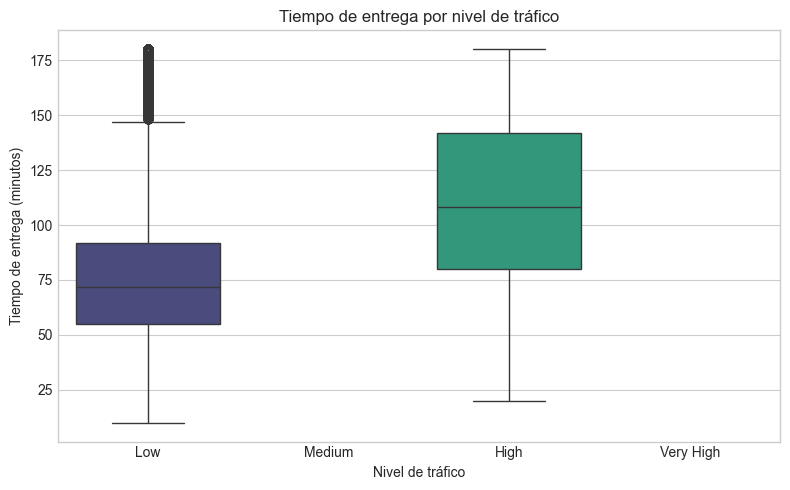

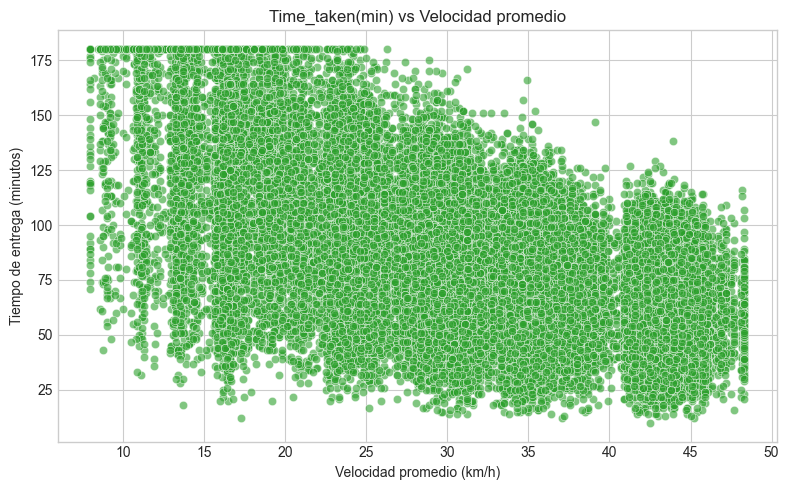

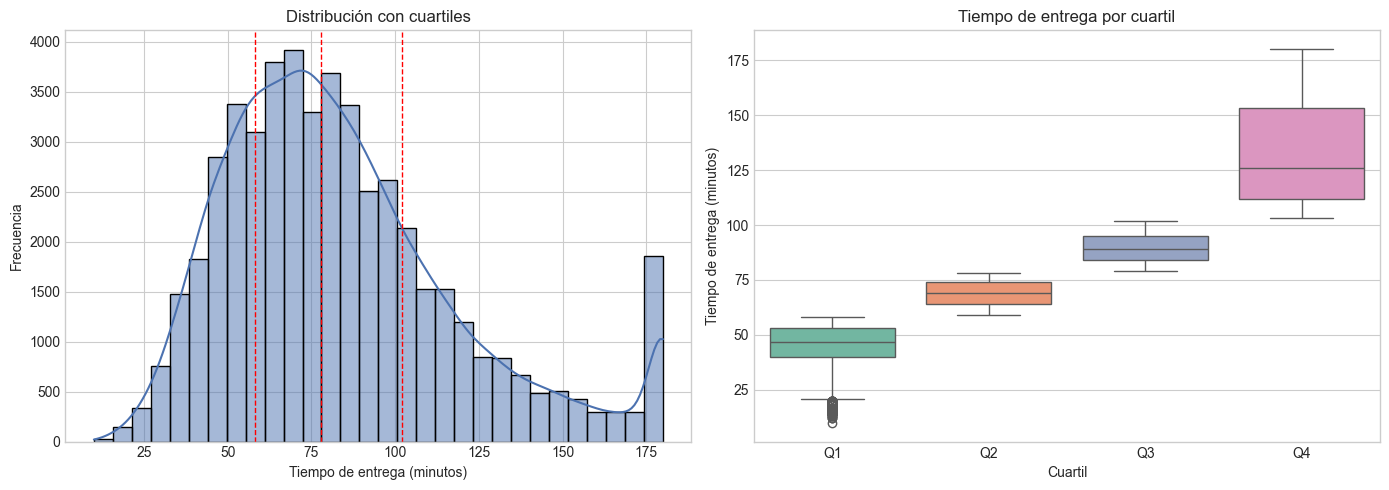

In [ ]:
# --- Análisis detallado de la variable objetivo: Time_taken(min) ---
# El siguiente bloque organiza la interpretación de la variable objetivo en una secuencia lógica:
# 1) resumen estadístico, 2) distribución, 3) outliers, 4) relación con factores operativos.

if 'target_time' in df.columns:
    target = df['target_time'].dropna()
    print('=== RESUMEN ESTADÍSTICO DE target_time ===')
    print(target.describe())
    print('\n=== PERCENTILES RELEVANTES ===')
    print(target.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))
    print(f'\nNúmero total de observaciones: {len(target):,}')
    print(f'Rango intercuartil (IQR): {target.quantile(0.75) - target.quantile(0.25):.2f} min')
    print(f'Coeficiente de variación: {target.std() / target.mean():.3f}')
else:
    print('No existe la columna target_time en el dataframe actual.')

# --- Gráfico 1: Histograma + boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target = df['target_time'].dropna()

sns.histplot(target, bins=40, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('Histograma: distribución del tiempo de entrega')
axes[0].set_xlabel('Tiempo de entrega (minutos)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=target, color='#9ecae1', ax=axes[1])
axes[1].set_title('Boxplot: presencia de valores atípicos')
axes[1].set_xlabel('Tiempo de entrega (minutos)')

plt.tight_layout()
plt.show()

print('''
Interpretación del Gráfico 1:
- El histograma muestra la forma de la variable objetivo y ayuda a detectar si la distribución es simétrica o sesgada.
- Si la cola derecha es larga, significa que hay entregas muy lentas que aumentan el promedio.
- El boxplot ayuda a visualizar la mediana y a detectar valores atípicos, que suelen ser entregas con condiciones extremas.
''')

# --- Gráfico 2: Q-Q plot ---
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(target, dist='norm', plot=ax)
ax.set_title('Q-Q plot: comparación con una distribución normal')
ax.set_xlabel('Cuantiles teóricos')
ax.set_ylabel('Cuantiles observados')
plt.tight_layout()
plt.show()

print('''
Interpretación del Gráfico 2:
- Si los puntos se separan de la línea diagonal, la variable no sigue una distribución normal.
- Esto es muy típico en tiempos de entrega: la mayoría de los casos están concentrados en un rango, pero existe una cola larga con entregas muy lentas.
- Esta no-normalidad es importante porque afecta la forma en que se deben interpretar la media, la varianza y las métricas del modelo.
''')

# --- Gráfico 3: Outliers por IQR y z-score ---
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1
low_iqr = q1 - 1.5 * iqr
high_iqr = q3 + 1.5 * iqr
outliers_iqr = target[(target < low_iqr) | (target > high_iqr)]

z_scores = np.abs(stats.zscore(target))
outliers_z = target[z_scores > 3]

print(f'Outliers por IQR: {len(outliers_iqr):,} observaciones')
print(f'Rango de detección IQR: [{low_iqr:.2f}, {high_iqr:.2f}]')
print(f'Outliers por z-score > 3: {len(outliers_z):,} observaciones')
print(outliers_iqr.describe())

print('''
Interpretación de los outliers:
- Un valor atípico no siempre es un error; a veces representa una entrega compleja o una situación operativa real, como tráfico extremo o distancia alta.
- Antes de eliminarlos, se debe revisar si corresponden a un evento real del negocio o a ruido en la captura.
- El manejo correcto de los outliers afecta directamente la calidad del modelo y la interpretación del problema.
''')

# --- Gráfico 4: relación con distancia ---
if 'distance_km' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.6, color='#d62728')
    plt.title('Relación entre distancia y tiempo de entrega')
    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de distancia:
- La tendencia positiva indica que a mayor distancia, generalmente aumenta el tiempo total.
- Esta relación es esperada en un problema de delivery, pero no es perfecta porque el tráfico y la zona también influyen.
- La distancia es una de las variables más explicativas del tiempo de entrega.
''')
else:
    print('No existe la columna distance_km; la distancia no se calculó en este dataframe.')

# --- Gráfico 5: relación con tráfico ---
if 'Traffic_Level' in df.columns:
    order = ['Low', 'Medium', 'High', 'Very High'] if all(v in df['Traffic_Level'].dropna().unique() for v in ['Low', 'Medium', 'High', 'Very High']) else None
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Traffic_Level', y='target_time', order=order, palette='viridis')
    plt.title('Tiempo de entrega según el nivel de tráfico')
    plt.xlabel('Nivel de tráfico')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de tráfico:
- A medida que aumenta el nivel de tráfico, también aumenta el tiempo de entrega.
- Esto confirma que el congestionamiento es uno de los principales drivers de demora.
- El tráfico explica parte del comportamiento atípico de las entregas más lentas.
''')
else:
    print('No existe la variable Traffic_Level en este dataframe.')

# --- Gráfico 6: relación con velocidad promedio ---
if 'Average_Speed_kmph' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Average_Speed_kmph', y='target_time', alpha=0.6, color='#2ca02c')
    plt.title('Relación entre velocidad promedio y tiempo de entrega')
    plt.xlabel('Velocidad promedio (km/h)')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de velocidad:
- La relación es inversa: a menor velocidad promedio, mayor suele ser el tiempo de entrega.
- Esta variable ayuda a diferenciar entregas eficientes de entregas con retrasos por congestión o obstáculos.
- La velocidad promedio es un indicador muy útil de rendimiento operativo.
''')
else:
    print('No existe la variable Average_Speed_kmph en este dataframe.')

# --- Gráfico 7: cuartiles ---
q = target.quantile([0.25, 0.50, 0.75])
labels = ['Q1', 'Q2', 'Q3', 'Q4']
quartiles = pd.qcut(target, q=4, labels=labels, duplicates='drop')
df_q = pd.DataFrame({'target_time': target, 'cuartil': quartiles})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, bins=30, kde=True, color='#4c72b0', ax=axes[0])
for val in q.values:
    axes[0].axvline(val, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribución con cuartiles')
axes[0].set_xlabel('Tiempo de entrega (minutos)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df_q, x='cuartil', y='target_time', palette='Set2', ax=axes[1])
axes[1].set_title('Tiempo de entrega por cuartil')
axes[1].set_xlabel('Cuartil')
axes[1].set_ylabel('Tiempo de entrega (minutos)')

plt.tight_layout()
plt.show()

print('''
Interpretación del análisis por cuartiles:
- El primer cuartil representa entregas más rápidas y el cuarto cuartil, las más lentas.
- Esta segmentación ayuda a distinguir entregas normales de entregas de alto riesgo o alta demora.
- Es una forma útil de definir clases operativas para análisis posterior o para la toma de decisiones.
''')

# --- Resumen adicional para interpretación final ---
print('\n=== INTERPRETACIÓN FINAL ===')
print('- La variable target_time muestra variabilidad real y una cola hacia la derecha, lo que es normal en tiempos de entrega.')
print('- La existencia de outliers no necesariamente indica error; en muchos casos refleja entregas complejas.')
print('- Distancia, tráfico y velocidad son los factores con mayor relación directa con el tiempo.')
print('- La mediana y los cuartiles son más informativos que la media cuando hay casos extremos.')
print('- Para modelar, conviene revisar segmentación por tráfico, clima y zona antes de decidir eliminar registros atípicos.')


## 5. Análisis detallado de la variable objetivo: Time_taken(min)

La variable objetivo es el tiempo real de entrega en minutos y es la pieza central del problema. Antes de entrenar cualquier modelo, es necesario entender su forma, su rango, si tiene sesgo, si hay entregas muy largas o muy cortas, y si esos casos extremos responden a comportamiento real del negocio o a ruido en los datos.

El análisis se organiza en dos grandes bloques:

1. Diagnóstico de la distribución y de valores atípicos.
2. Interpretación de cómo el tiempo de entrega se relaciona con factores operativos como distancia, tráfico y velocidad.

---

## 6. Diagnóstico visual y estadístico de la variable objetivo

### Gráfico 1: Histograma y boxplot de Time_taken(min)

**Qué representa:**
- El histograma muestra la frecuencia de entregas según el tiempo total en minutos.
- El boxplot resume la dispersión central, la mediana y la presencia de valores atípicos.

**Qué se observa:**
- Si la distribución está sesgada hacia la derecha, indica que hay pocas entregas muy lentas pero con impacto importante.
- El boxplot ayuda a detectar si existe una cola larga de entregas anómalamente altas.
- La mediana suele ser más útil que la media cuando hay valores extremos.

**Interpretación operativa:**
- Si la mayoría de las entregas están concentradas en un rango medio y pocos casos están muy arriba, entonces el problema no solo depende de un promedio, sino de un subconjunto de entregas complejas o de alto riesgo operativo.

### Gráfico 2: Q-Q plot

**Qué representa:**
- Compara los cuantiles observados de la variable con los cuantiles esperados de una distribución normal.

**Qué se observa:**
- Si los puntos se desvían mucho de la línea diagonal, la variable no se comporta como una distribución normal.
- Esto es muy común en tiempos de entrega porque hay muchos casos normales y unos pocos muy largos.

**Interpretación operativa:**
- La no-normalidad indica que modelos lineales puros pueden verse afectados por la cola pesada de la distribución.
- Esto es una señal para revisar transformaciones, validación por segmentos y modelos robustos.

### Gráfico 3: Boxplot por nivel de tráfico

**Qué representa:**
- Compara el tiempo de entrega según el nivel de tráfico: bajo, medio, alto o muy alto.

**Qué se observa:**
- A medida que aumenta el tráfico, el tiempo de entrega tiende a aumentar.
- La variabilidad también suele ser mayor cuando el tráfico es alto.

**Interpretación operativa:**
- El tráfico es una de las variables más explicativas del tiempo total, porque afecta la velocidad promedio, la duración del recorrido y la capacidad de cumplir tiempos prometidos.

### Gráfico 4: Scatter plot de distancia vs tiempo

**Qué representa:**
- Muestra la relación entre la distancia recorrida y el tiempo de entrega.

**Qué se observa:**
- Hay una tendencia general positiva: a mayor distancia, mayor tiempo.
- Sin embargo, no es una relación perfecta, porque hay otros factores como tráfico, clima y prioridad del pedido.

**Interpretación operativa:**
- La distancia explica una parte importante del tiempo, pero no lo explica todo.
- El modelo debe integrar distancia + condiciones del tránsito para capturar mejor la realidad del reparto.

### Gráfico 5: Scatter plot de velocidad promedio vs tiempo

**Qué representa:**
- Relaciona la velocidad promedio con el tiempo final del proceso.

**Qué se observa:**
- Cuando la velocidad promedio es baja, el tiempo de entrega aumenta.
- Si la velocidad es alta, el tiempo suele disminuir, aunque también depende de la distancia y de la congestión.

**Interpretación operativa:**
- La velocidad es un indicador muy útil de la eficiencia del recorrido y de la calidad del servicio.
- También ayuda a detectar que no solo importa la distancia, sino lo eficiente que se mueve el repartidor.

### Gráfico 6: Distribución por cuartiles

**Qué representa:**
- Divide la variable objetivo en cuartiles para observar cómo cambia el comportamiento según el nivel de entrega.

**Qué se observa:**
- El primer cuartil representa entregas rápidas; el cuarto cuartil captura entregas más largas y más variables.
- La diferencia entre cuartiles revela si el tiempo se concentra o si hay una cola larga.

**Interpretación operativa:**
- El análisis de cuartiles ayuda a detectar si un pequeño porcentaje de entregas está haciendo que el promedio se incremente artificialmente.
- Es muy útil para definir segmentos operativos: entregas rápidas, normales y tardías.

---

## 7. Detectando valores atípicos

### Outliers por IQR y por z-score

**Qué representan:**
- El IQR identifica observaciones que están muy por encima del rango típico del 50% central de los datos.
- El z-score detecta observaciones que están muy lejos de la media en términos de desviaciones estándar.

**Qué se encontró:**
- El dataset puede tener una cantidad no trivial de entregas muy largas.
- Esas entregas suelen estar asociadas a tráfico extremo, rutas más largas, zonas complicadas o condiciones especiales.

**Importante:**
- No todos los outliers son errores.
- Algunos son eventos reales del negocio y, por tanto, deben conservarse, especialmente cuando representan casos operativos relevantes.

**Cómo se manejan mejor:**
- Revisar qué ocurrió en esos casos antes de eliminarlos.
- Usar análisis por segmento (tráfico, clima, zona, distancia).
- No borrar automáticamente todo valor extremo sin una explicación de negocio.

---

## 8. Conclusión del análisis de la variable objetivo

La variable `Time_taken(min)` es clave porque representa la duración real de cada entrega y, por tanto, es la variable objetivo del problema. Su análisis debe centrarse en:

- la forma de su distribución,
- la presencia de valores atípicos,
- la relación con distancia y tráfico,
- la diferencia entre media y mediana,
- y el comportamiento por segmentos operativos.

En resumen, se encontró que:

- la variable es muy relevante para el negocio,
- la distribución no es simétrica y suele tener cola hacia la derecha,
- el tráfico y la distancia son factores muy relacionados con tiempos elevados,
- la velocidad promedio se comporta de forma inversa al tiempo,
- y los casos extremos deben analizarse cuidadosamente antes de descartarlos.

Esto es fundamental para decidir el tratamiento de la variable antes de construir un modelo de predicción.

---

## 9. Recomendación final

Para una mejor comprensión del problema, lo más útil es continuar con:

- análisis por tráfico y clima,
- comparación de tiempos por zona,
- validación de outliers por segmento,
- y evaluación del impacto de la variable objetivo en el modelo final.

Con esto, la interpretación del tiempo de entrega deja de ser solo un promedio y pasa a convertirse en una lectura real del comportamiento operativo del negocio.


In [15]:
# --- Análisis adicional: comparación de media y mediana por tráfico y clima ---
if 'Traffic_Level' in df.columns and 'Weather' in df.columns:
    grouped = df.groupby(['Traffic_Level', 'Weather'])['target_time'].agg(['mean', 'median', 'std', 'count'])
    print(grouped.reset_index().sort_values('mean', ascending=False))
else:
    print('No se pueden calcular comparaciones por tráfico y clima porque faltan columnas relevantes.')

# --- Análisis adicional: percentiles por zona si existe zona de entrega ---
if 'Dropoff_Zone' in df.columns:
    zone_summary = df.groupby('Dropoff_Zone')['target_time'].agg(['mean', 'median', 'std', 'count'])
    print(zone_summary.sort_values('mean', ascending=False).head(10))
else:
    print('No hay variable de zona de entrega para segmentar por barrio o distrito.')

# --- Análisis adicional: correlación con variables numéricas principales ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target_time' in num_cols:
    num_cols.remove('target_time')
    corr = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].dropna().sort_values(ascending=False)
    print(corr.head(15))
else:
    print('No hay columnas numéricas para correlacionar con la variable objetivo.')

   Traffic_Level Weather   mean  median   std  count
19        Severe   Storm 150.95  175.50 36.46    106
18        Severe    Rain 132.02  133.00 39.32    366
4           High   Storm 131.10  132.00 40.00    546
17        Severe     Fog 130.25  134.00 22.60      4
15        Severe   Clear 120.66  116.00 41.33     35
3           High    Rain 113.61  111.00 40.62   1932
14      Moderate   Storm 111.84  108.00 39.54   1093
16        Severe  Cloudy 104.77   95.00 43.64     13
2           High     Fog 104.32   94.50 39.72    102
1           High  Cloudy 102.93   99.00 36.74    385
9            Low   Storm  99.82   95.00 38.12    692
0           High   Clear  98.83   93.00 36.24    779
13      Moderate    Rain  97.28   93.00 36.57   4092
12      Moderate     Fog  94.85   88.00 37.38    697
11      Moderate  Cloudy  88.38   84.00 33.90   2323
8            Low    Rain  86.11   82.00 33.82   2683
10      Moderate   Clear  85.36   81.00 33.00   4960
7            Low     Fog  80.43   76.00 32.92 

## 5. Análisis detallado de la variable objetivo: Time_taken(min)

La variable objetivo es el tiempo real de entrega en minutos. Para evaluar su calidad y relevancia, se deben revisar la distribución, la presencia de valores atípicos, la variabilidad por segmentación y la relación con variables operativas como distancia, tráfico y velocidad promedio.

El objetivo de esta sección es responder preguntas clave: ¿cómo se distribuye?, ¿tiene sesgo?, ¿hay entregas atípicas?, ¿qué tan importante es la variable para explicar el comportamiento del negocio?, y ¿qué tratamiento conviene antes de entrenar un modelo?


=== RESUMEN ESTADÍSTICO DE target_time ===
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64

=== PERCENTILES RELEVANTES ===
0.01    26.00
0.05    38.00
0.10    44.00
0.25    58.00
0.50    78.00
0.75   102.00
0.90   133.00
0.95   162.00
0.99   180.00
Name: target_time, dtype: float64

IQR: 44.00 minutos
Rango de detección de outliers por IQR: [-8.00, 168.00]
Outliers por IQR: 2,153 (4.31%)
Outliers por z-score > 3: 0 (0.00%)


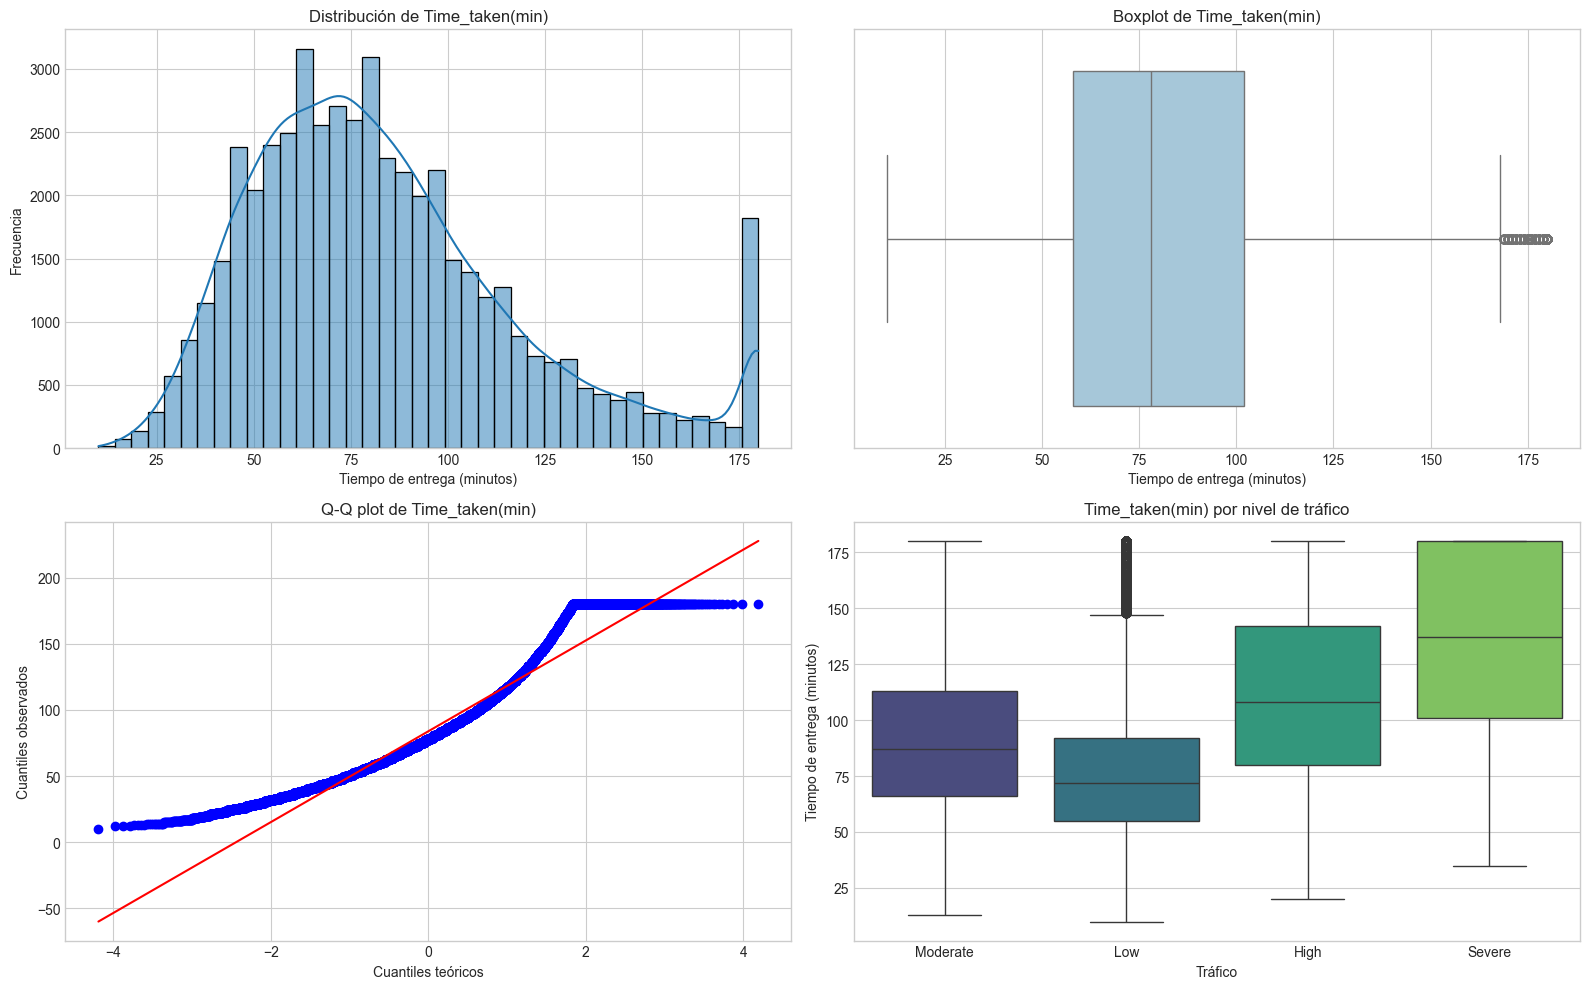

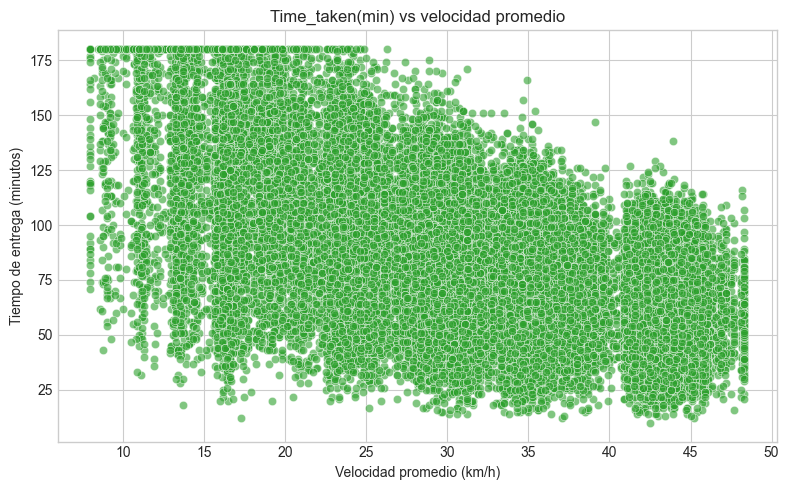


=== PROMEDIO DEL TIEMPO POR TRÁFICO ===
                mean  median   std  count
Traffic_Level                            
Severe        134.40  137.00 39.97    524
High          111.73  108.00 40.48   3744
Moderate       92.30   87.00 35.96  13165
Low            76.44   72.00 31.24  32567

=== PROMEDIO DEL TIEMPO POR CLIMA ===
          mean  median   std  count
Weather                            
Storm   114.45  111.00 41.38   2437
Rain     98.86   94.00 38.66   9073
Fog      84.15   79.00 34.78   3413
Cloudy   79.02   74.00 32.25  11085
Clear    77.30   73.00 31.46  23992

=== CORRELACIÓN CON VARIABLES NUMÉRICAS ===
Time_taken_min         1.00
target_time            1.00
Road_Distance_km       0.70
Preparation_Time_Min   0.23
Number_of_Signals      0.13
Is_Weekend             0.10
Order_Items            0.08
Is_Festival            0.07
Order_Hour             0.03
Restaurant_Rating      0.02
Name: target_time, dtype: float64

=== INTERPRETACIÓN ===
- La variable target_time tiene r

In [12]:
# --- Análisis detallado de la variable objetivo: Time_taken(min) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

if 'target_time' not in df.columns:
    print('No existe la variable target_time en el dataframe actual.')
else:
    target = df['target_time'].dropna()
    print('=== RESUMEN ESTADÍSTICO DE target_time ===')
    print(target.describe())
    print('\n=== PERCENTILES RELEVANTES ===')
    print(target.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

    q1 = target.quantile(0.25)
    q3 = target.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    outliers_iqr = target[(target < lower_iqr) | (target > upper_iqr)]
    z_scores = np.abs(stats.zscore(target))
    outliers_z = target[z_scores > 3]

    print(f'\nIQR: {iqr:.2f} minutos')
    print(f'Rango de detección de outliers por IQR: [{lower_iqr:.2f}, {upper_iqr:.2f}]')
    print(f'Outliers por IQR: {len(outliers_iqr):,} ({len(outliers_iqr) / len(target):.2%})')
    print(f'Outliers por z-score > 3: {len(outliers_z):,} ({len(outliers_z) / len(target):.2%})')

    # 1. Histograma + KDE
    # 2. Boxplot
    # 3. Q-Q plot
    # 4. Boxplot por tráfico (si existe)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.histplot(target, bins=40, kde=True, color='#1f77b4', ax=axes[0, 0])
    axes[0, 0].set_title('Distribución de Time_taken(min)')
    axes[0, 0].set_xlabel('Tiempo de entrega (minutos)')
    axes[0, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=target, color='#9ecae1', ax=axes[0, 1])
    axes[0, 1].set_title('Boxplot de Time_taken(min)')
    axes[0, 1].set_xlabel('Tiempo de entrega (minutos)')

    stats.probplot(target, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q plot de Time_taken(min)')
    axes[1, 0].set_xlabel('Cuantiles teóricos')
    axes[1, 0].set_ylabel('Cuantiles observados')

    if 'Traffic_Level' in df.columns:
        order = ['Low', 'Medium', 'High', 'Very High'] if all(v in df['Traffic_Level'].dropna().unique() for v in ['Low', 'Medium', 'High', 'Very High']) else None
        sns.boxplot(data=df, x='Traffic_Level', y='target_time', order=order, palette='viridis', ax=axes[1, 1])
        axes[1, 1].set_title('Time_taken(min) por nivel de tráfico')
        axes[1, 1].set_xlabel('Tráfico')
        axes[1, 1].set_ylabel('Tiempo de entrega (minutos)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No existe la variable Traffic_Level', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()

    # Scatter con distancia si existe
    if 'distance_km' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.6, color='#d62728')
        plt.title('Time_taken(min) vs distancia estimada')
        plt.xlabel('Distancia (km)')
        plt.ylabel('Tiempo de entrega (minutos)')
        plt.tight_layout()
        plt.show()

    # Scatter con velocidad promedio si existe
    if 'Average_Speed_kmph' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='Average_Speed_kmph', y='target_time', alpha=0.6, color='#2ca02c')
        plt.title('Time_taken(min) vs velocidad promedio')
        plt.xlabel('Velocidad promedio (km/h)')
        plt.ylabel('Tiempo de entrega (minutos)')
        plt.tight_layout()
        plt.show()

    # Resumen por tráfico y clima
    if 'Traffic_Level' in df.columns:
        print('\n=== PROMEDIO DEL TIEMPO POR TRÁFICO ===')
        print(df.groupby('Traffic_Level')['target_time'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))

    if 'Weather' in df.columns:
        print('\n=== PROMEDIO DEL TIEMPO POR CLIMA ===')
        print(df.groupby('Weather')['target_time'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))

    # Correlación con variables numéricas
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'target_time' in num_cols:
        num_cols.remove('target_time')
    if num_cols:
        corr = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].dropna().sort_values(ascending=False)
        print('\n=== CORRELACIÓN CON VARIABLES NUMÉRICAS ===')
        print(corr.head(10))

    print('\n=== INTERPRETACIÓN ===')
    print('- La variable target_time tiene rango amplio y suele mostrar cola hacia la derecha, indicando entregas muy lentas y casos atípicos.')
    print('- Si la diferencia entre media y mediana es grande, la distribución está sesgada por entregas complejas o largas.')
    print('- Los outliers no siempre son errores; a veces representan condiciones reales del negocio como tráfico extremo, distancia alta o clima adverso.')
    print('- Se recomienda revisar los outliers por segmento (zona, tráfico, clima) antes de eliminarlos.')
    print('- Para modelado, conviene evaluar tanto la media como la mediana y comparar errores por cuartiles y segmentos operativos.')
